In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import glob
import time
import scipy
import scipy.sparse as sp
from scipy.sparse import csr_matrix, issparse
import anndata as an
import scanpy as sc
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import matplotlib.patches as mpatches
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from itertools import chain
import re
import pickle as pkl
from sklearn.decomposition import TruncatedSVD
import pyarrow
from sklearn.preprocessing import MinMaxScaler
import cooler
import pairtools

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as mtrx
import utils as ut
#import plotting as plt2
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central


/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
path_clean = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/singlecell_mESC_1000000_raw.h5ad"

start_time = time.time()  # Record the start time
cdata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 234.80 seconds
Memory usage: current 27.55 GB, difference +27.55 GB


In [3]:
mask = cdata.obs_names.str.startswith("chr8:")
cdata_filtered = cdata[mask, :].copy()

In [4]:
cdata_filtered.obs.head()

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes
bin_name,,,,,,,,,
chr8:20,20,20000000,21000000,1162,8,20,161846,Gm40466;Gm20778;6820431F20Rik;2610005L07Rik;Po...,12
chr8:21,25,21000000,22000000,1163,8,21,121164,Defa-ps7;Gm56829;Defa27;Defa23;Potefam3b;Gm207...,28
chr8:80,27,80000000,81000000,1222,8,80,69908,Gm33096;Gm45601;Gm27006;Mmaa;Gm8077;Hhip;Smad1...,16
chr8:43,49,43000000,44000000,1185,8,43,33751,Adam26b;Gm6284;Gm2221;Zfp42;Triml1;Triml2,6
chr8:114,56,114000000,115000000,1256,8,114,40206,Syce1l;Gm30052;Nudt7;Vat1l;Mon1b;Gm56821;Adamts18,7


In [53]:
path_clean = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_1000000_raw.h5ad"

start_time = time.time()  # Record the start time
adata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 25.12 seconds
Memory usage: current 33.42 GB, difference +5.94 GB


In [ ]:
mask = adata.obs_names.str.startswith("chr8:")
adata_filtered = adata[mask, :].copy()

In [84]:
adata_filtered.X.toarray()[:5]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 2756467))

In [ ]:
adata_filtered.obs = adata_filtered.obs.sort_values(['chrom_bin'])

In [5]:
def load_pairs(filepath):
    """Load a .pairs file with extended column set"""
    
    cols = [
        "readID", "chrom1", "pos1", "chrom2", "pos2",
        "strand1", "strand2", "pair_type",
        "walk_pair_index", "walk_pair_type",
        "mapq1", "mapq2",
        "read_len1", "read_len2",
        "algn_read_span1", "algn_read_span2",
        "algn_ref_span1", "algn_ref_span2",
        "matched_bp1", "matched_bp2",
        "rfrag1", "rfrag_start1", "rfrag_end1",
        "rfrag2", "rfrag_start2", "rfrag_end2"
    ]
    
    df = pd.read_csv(
        filepath,
        sep="\t",
        comment="#",
        header=None,
        names=cols
    )
    
    # Cast numeric columns
    int_cols = [
        "pos1", "pos2",
        "mapq1", "mapq2",
        "read_len1", "read_len2",
        "algn_read_span1", "algn_read_span2",
        "algn_ref_span1", "algn_ref_span2",
        "matched_bp1", "matched_bp2",
        "rfrag1", "rfrag_start1", "rfrag_end1",
        "rfrag2", "rfrag_start2", "rfrag_end2"
    ]
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors="coerce")
    
    return df

In [6]:
def filter_pairs(df, min_mapq=30, valid_pair_types=None):
    """
    Filter contacts by quality metrics.
    
    Parameters:
        min_mapq         : minimum mapping quality for both reads
        valid_pair_types : list of pair_type values to keep
                           e.g. ['UU', 'RU', 'UR'] for unique alignments
                           None = no pair_type filter
    """
    original_len = len(df)
    
    # Filter by mapping quality
    df = df[(df["mapq1"] >= min_mapq) & (df["mapq2"] >= min_mapq)]
    
    # Filter by pair type (e.g. keep only uniquely mapped pairs)
    if valid_pair_types is not None:
        df = df[df["pair_type"].isin(valid_pair_types)]
    
    # Remove unmapped or low-confidence pair types
    exclude_types = ["NN", "NM", "MN", "XX"]  # adjust as needed
    df = df[~df["pair_type"].isin(exclude_types)]
    
    print(f"Retained {len(df)}/{original_len} contacts after filtering "
          f"({len(df)/original_len*100:.1f}%)")
    
    return df

In [7]:
def build_contact_matrix(df, chrom, bin_size=50_000):
    """
    Build an intra-chromosomal contact matrix for one chromosome.

    Returns (matrix, max_bin) so callers can align sizes across cells.
    """
    intra = df[(df["chrom1"] == chrom) & (df["chrom2"] == chrom)].copy()
    print(f"    {len(intra)} intra-chromosomal contacts on {chrom}")
    intra = intra.dropna(subset=["pos1", "pos2"])
    intra["bin1"] = (intra["pos1"] // bin_size).astype(int)
    intra["bin2"] = (intra["pos2"] // bin_size).astype(int)

    if intra.empty:
        return np.zeros((0, 0), dtype=float), 0

    max_bin = int(max(intra["bin1"].max(), intra["bin2"].max())) + 1
    matrix = np.zeros((max_bin, max_bin), dtype=float)
    np.add.at(matrix, (intra["bin1"].values, intra["bin2"].values), 1)
    np.add.at(matrix, (intra["bin2"].values, intra["bin1"].values), 1)
    return matrix, max_bin

In [8]:
def build_whole_genome_matrix(df, chrom_sizes, bin_size=50_000):
    """
    Build a whole-genome contact matrix using a provided chrom_sizes dict.

    Parameters
    ----------
    df          : filtered pairs DataFrame
    chrom_sizes : dict  {chrom_name: length_in_bp}
                  Only chromosomes present in this dict are included.
                  Example: {"chr1": 195471971, "chr2": 182113224, ...}
    bin_size    : genomic bin width in bp

    Returns
    -------
    matrix      : np.ndarray, shape (total_bins, total_bins)
    chrom_offsets: dict mapping chrom_name -> first bin index in the matrix
    """
    # Build ordered offset table
    chrom_offsets = {}
    offset = 0
    for chrom, length in chrom_sizes.items():
        chrom_offsets[chrom] = offset
        offset += int(np.ceil(length / bin_size))
    total_bins = offset

    matrix = np.zeros((total_bins, total_bins), dtype=float)

    # Only keep rows where both chroms are in our reference set
    mask = df["chrom1"].isin(chrom_offsets) & df["chrom2"].isin(chrom_offsets)
    sub = df[mask].dropna(subset=["pos1", "pos2"]).copy()
    print(f"    {len(sub)} contacts mapping to reference chromosomes")

    bin1 = (sub["pos1"] // bin_size).astype(int) + sub["chrom1"].map(chrom_offsets)
    bin2 = (sub["pos2"] // bin_size).astype(int) + sub["chrom2"].map(chrom_offsets)

    np.add.at(matrix, (bin1.values, bin2.values), 1)
    np.add.at(matrix, (bin2.values, bin1.values), 1)

    return matrix, chrom_offsets

In [9]:
def build_master_matrix(
    directory,
    bin_size=50_000,
    chrom=None,
    chrom_sizes=None,
    min_mapq=30,
    valid_pair_types=None,
    suffix=".GRCm39.filtered.pairs"
):
    """
    Read all *{suffix} files in `directory`, filter them, and accumulate
    contacts into a single master numpy matrix.

    Parameters
    ----------
    directory        : path to folder containing .pairs files
    bin_size         : genomic bin width in bp
    chrom            : str or None
                       • str  → single-chromosome intra mode (e.g. "chr1")
                       • None → whole-genome mode (requires chrom_sizes)
    chrom_sizes      : dict {chrom: length} required when chrom=None
    min_mapq         : passed to filter_pairs
    valid_pair_types : passed to filter_pairs
    suffix           : filename suffix used to glob for files

    Returns
    -------
    master_matrix : np.ndarray  — aggregated contact matrix
    file_list     : list of file paths that were processed
    """
    pattern = os.path.join(directory, f"*{suffix}")
    file_list = sorted(glob.glob(pattern))

    if not file_list:
        raise FileNotFoundError(
            f"No files matching '*{suffix}' found in: {directory}"
        )
    print(f"Found {len(file_list)} pairs file(s) in '{directory}'")

    # ── Whole-genome mode validation ──
    if chrom is None and chrom_sizes is None:
        raise ValueError(
            "Provide chrom_sizes dict when running in whole-genome mode "
            "(chrom=None)."
        )

    master_matrix = None

    for i, fpath in enumerate(file_list, 1):
        fname = os.path.basename(fpath)
        #print(f"\n[{i}/{len(file_list)}] Processing: {fname}")

        df = load_pairs(fpath)
        df = filter_pairs(df, min_mapq=min_mapq,
                          valid_pair_types=valid_pair_types)

        # ── Single-chromosome mode ──
        if chrom is not None:
            cell_matrix, max_bin = build_contact_matrix(df, chrom, bin_size)

            if cell_matrix.size == 0:
                print(f"    Skipping {fname}: no contacts on {chrom}")
                continue

            # Grow master matrix if this cell is larger
            if master_matrix is None:
                master_matrix = cell_matrix.copy()
            else:
                current_size = master_matrix.shape[0]
                if max_bin > current_size:
                    # Pad master to new size
                    padded = np.zeros((max_bin, max_bin), dtype=float)
                    padded[:current_size, :current_size] = master_matrix
                    master_matrix = padded
                # Add cell matrix (pad cell if smaller than master)
                cell_size = cell_matrix.shape[0]
                master_matrix[:cell_size, :cell_size] += cell_matrix

        # ── Whole-genome mode ──
        else:
            cell_matrix, _ = build_whole_genome_matrix(
                df, chrom_sizes, bin_size
            )
            if master_matrix is None:
                master_matrix = cell_matrix.copy()
            else:
                master_matrix += cell_matrix   # sizes are fixed by chrom_sizes

    if master_matrix is None:
        raise RuntimeError("No contacts were loaded — master matrix is empty.")

    print(f"\nMaster matrix shape: {master_matrix.shape}")
    print(f"Total contacts (sum/2): {int(master_matrix.sum() / 2)}")
    return master_matrix, file_list

In [10]:
directory = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/single_cell/single_cell/direct"

# ── Single chromosome ─────────────────────────────────────────────────────────
master_chr, files = build_master_matrix(
    directory=directory,
    bin_size=1_000_000,
    chrom="8",
    min_mapq=30,
    valid_pair_types=["UU", "RU", "UR"]
)


Found 380 pairs file(s) in '/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/single_cell/single_cell/direct'
Retained 127/222 contacts after filtering (57.2%)
    6 intra-chromosomal contacts on 8
Retained 2780/4962 contacts after filtering (56.0%)
    30 intra-chromosomal contacts on 8
Retained 3674/6792 contacts after filtering (54.1%)
    53 intra-chromosomal contacts on 8
Retained 7459/13603 contacts after filtering (54.8%)
    97 intra-chromosomal contacts on 8
Retained 5294/9571 contacts after filtering (55.3%)
    93 intra-chromosomal contacts on 8
Retained 6808/12565 contacts after filtering (54.2%)
    69 intra-chromosomal contacts on 8
Retained 4742/8475 contacts after filtering (56.0%)
    72 intra-chromosomal contacts on 8
Retained 4818/8994 contacts after filtering (53.6%)
    46 intra-chromosomal contacts on 8
Retained 3868/7075 contacts after filtering (54.7%)
    47 intra-chromosomal contacts on 8
Retained 4762/8636 contacts after filtering (55.1%)
    59 

In [73]:
directory_2 = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/population/direct/pairs"

master_pop, files = build_master_matrix(
    directory=directory_2,
    bin_size=1_000_000,
    chrom="8",
    min_mapq=30,
    valid_pair_types=["UU", "RU", "UR"],
    suffix=".GRCm39.direct.pairs",
)

Found 4 pairs file(s) in '/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/population/direct/pairs'
Retained 392334/2190619 contacts after filtering (17.9%)
    12054 intra-chromosomal contacts on 8
Retained 39848/239511 contacts after filtering (16.6%)
    1329 intra-chromosomal contacts on 8
Retained 226720/1371927 contacts after filtering (16.5%)
    7060 intra-chromosomal contacts on 8
Retained 442715/2354884 contacts after filtering (18.8%)
    14528 intra-chromosomal contacts on 8

Master matrix shape: (131, 131)
Total contacts (sum/2): 34971


In [ ]:
mm39_chrom_sizes = {
    "1":  195154279,
    "2":  181755017,
    "3":  159745316,
    "4":  156860686,
    "5":  151758149,
    "6":  149588044,
    "7":  144995196,
    "8":  130127694,
    "9":  124359700,
    "10": 130530862,
    "11": 121973369,
    "12": 120092757,
    "13": 120883175,
    "14": 125139656,
    "15": 104073951,
    "16": 98008968,
    "17": 95294699,
    "18": 90720763,
    "19": 61420004,
    "X":  169476592,
}

master, files = build_master_matrix(
    directory=directory,
    bin_size=50_000,
    chrom=None,                   # whole-genome mode
    chrom_sizes=mm39_chrom_sizes,
    min_mapq=30,
    valid_pair_types=["UU", "RU", "UR"]
)

In [11]:
def clique_expand(incidence_matrix):
    """
    Clique-expand a sparse incidence matrix into a contact matrix.
    H @ H^T -> shape (n_bins, n_bins)

    Parameters
    ----------
    incidence_matrix : scipy.sparse.csr_matrix
        Sparse incidence matrix of shape (n_bins, n_reads).

    Returns
    -------
    contact_matrix : np.ndarray
        Dense contact matrix of shape (n_bins, n_bins).
    """
    H = incidence_matrix.astype(float).tocsr()
    return (H @ H.T).toarray()

In [12]:
def add_corner_colorbar(fig, ax, im, label, fontsize=7):
    """
    Add a small colorbar anchored to the bottom-right corner of an axes.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
        The parent axes the colorbar should sit inside.
    im : mappable
        The image/mappable to attach the colorbar to.
    label : str
        Colorbar label.
    fontsize : int
        Font size for colorbar tick labels and title.

    Returns
    -------
    cbar : matplotlib.colorbar.Colorbar
    """
    # Place a small inset axes in the bottom-right corner of the parent axes
    # [x0, y0, width, height] in axes-fraction coordinates
    cax = ax.inset_axes([0.72, 0.02, 0.25, 0.03])          # wide & short → horizontal bar
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label, fontsize=fontsize, labelpad=2)
    cbar.ax.tick_params(labelsize=fontsize - 1, length=2, pad=1)

    # Make the colorbar frame stand out slightly against the heatmap
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(0.8)

    return cbar

In [13]:
def plot_panel_contact(
    sparse_matrix,
    numpy_matrix_1,
    spath,
    titles,
    log_transform=True,
    cmap='Reds',
    dpi=200,
    figsize=(12, 6),
    xticklabel_interval=5,
    yticklabel_interval=5,
):
    """
    Plot three contact matrices side-by-side with a single small colorbar
    placed outside and below the bottom-right corner of the last panel.

    Parameters
    ----------
    sparse_matrix : scipy.sparse.csr_matrix
        Sparse incidence matrix to clique-expand (H @ H^T).
    numpy_matrix_1 : np.ndarray
        Pre-computed contact matrix (plotted as-is).
    numpy_matrix_2 : np.ndarray
        Pre-computed contact matrix (plotted as-is).
    spath : str
        Output file path for the saved figure.
    titles : tuple of str
        Subplot titles for the three panels.
    log_transform : bool
        If True, apply np.log1p to all three matrices before plotting.
    cmap : str
        Colormap for all three heatmaps.
    dpi : int
        Figure resolution.
    figsize : tuple
        Overall figure size (width, height) in inches.
    xticklabel_interval : int
        Show every Nth x-tick label.
    yticklabel_interval : int
        Show every Nth y-tick label.

    Returns
    -------
    axes : list of matplotlib.axes.Axes
    matrices : dict
        Raw (untransformed) matrices keyed by panel title.
    """

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    if not issparse(sparse_matrix):
        raise TypeError(
            f"sparse_matrix must be a scipy sparse matrix, got {type(sparse_matrix)}. "
            "Convert with scipy.sparse.csr_matrix(your_array)."
        )
    for name, mat in [('numpy_matrix_1', numpy_matrix_1)]:
        if not isinstance(mat, np.ndarray):
            raise TypeError(
                f"{name} must be a numpy ndarray, got {type(mat)}."
            )

    # ------------------------------------------------------------------
    # Build raw matrices
    # ------------------------------------------------------------------
    contact_sparse = clique_expand(sparse_matrix)
    contact_np1    = numpy_matrix_1.astype(float)

    raw_matrices = {
        titles[0]: contact_sparse,
        titles[1]: contact_np1,
    }

    # ------------------------------------------------------------------
    # Optional log transform
    # ------------------------------------------------------------------
    if log_transform:
        plot_matrices = [np.log1p(m) for m in
                         [contact_sparse, contact_np1]]
        cbar_label = 'log(1 + contacts)'
    else:
        plot_matrices = [contact_sparse, contact_np1]
        cbar_label = 'Contacts'

    # ------------------------------------------------------------------
    # Global style
    # ------------------------------------------------------------------
    plt.rcParams.update({
        'figure.dpi':     dpi,
        'axes.edgecolor': 'black',
        'axes.linewidth': 2.0,
        'font.family':    'sans-serif',
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ------------------------------------------------------------------
    # Draw each panel — no colorbar on any of them
    # ------------------------------------------------------------------
    for ax, data, title in zip(axes, plot_matrices, titles):

        sns.heatmap(
            data,
            ax=ax,
            cmap=cmap,
            square=True,
            cbar=False,
            linewidths=0,
            xticklabels=False,
            yticklabels=False,
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
            ha='right',
            fontsize=0,
        )
        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
            fontsize=0,
        )
        ax.set_xlabel('', fontsize=9, fontweight = 'bold')
        ax.set_ylabel('', fontsize=9, fontweight = 'bold')
        ax.set_title(title, fontsize=10, fontweight='bold', pad=6)

    # ------------------------------------------------------------------
    # Single small colorbar anchored just outside the last panel
    # ------------------------------------------------------------------
    # Use the mappable from the last axes
    last_im = axes[-1].collections[0]

    # Get the bounding box of the last axes in figure-fraction coordinates
    # so we can place the colorbar axes precisely relative to it
    plt.tight_layout()                      # must call before get_position()
    fig.canvas.draw()                       # flush layout engine

    last_pos = axes[-1].get_position()      # Bbox in figure fractions

    # Colorbar axes: narrow horizontal strip, sitting just below the
    # bottom-right corner of the last panel, outside the heatmap area.
    # [left, bottom, width, height]  — all in figure-fraction units
    cbar_width  = last_pos.width * 0.35     # 35 % of the last panel width
    cbar_height = 0.018                     # thin horizontal strip
    cbar_left   = last_pos.x1 - cbar_width  # right-aligned with last panel
    cbar_bottom = last_pos.y0 - 0.07        # just below the last panel

    cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])

    cbar = fig.colorbar(last_im, cax=cax, orientation='horizontal')
    cbar.set_label(cbar_label, fontsize=7, labelpad=3)
    cbar.ax.tick_params(labelsize=6, length=2, pad=1)
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(0.8)

    plt.savefig(spath, dpi=dpi, bbox_inches='tight')
    plt.show()

    return axes, raw_matrices

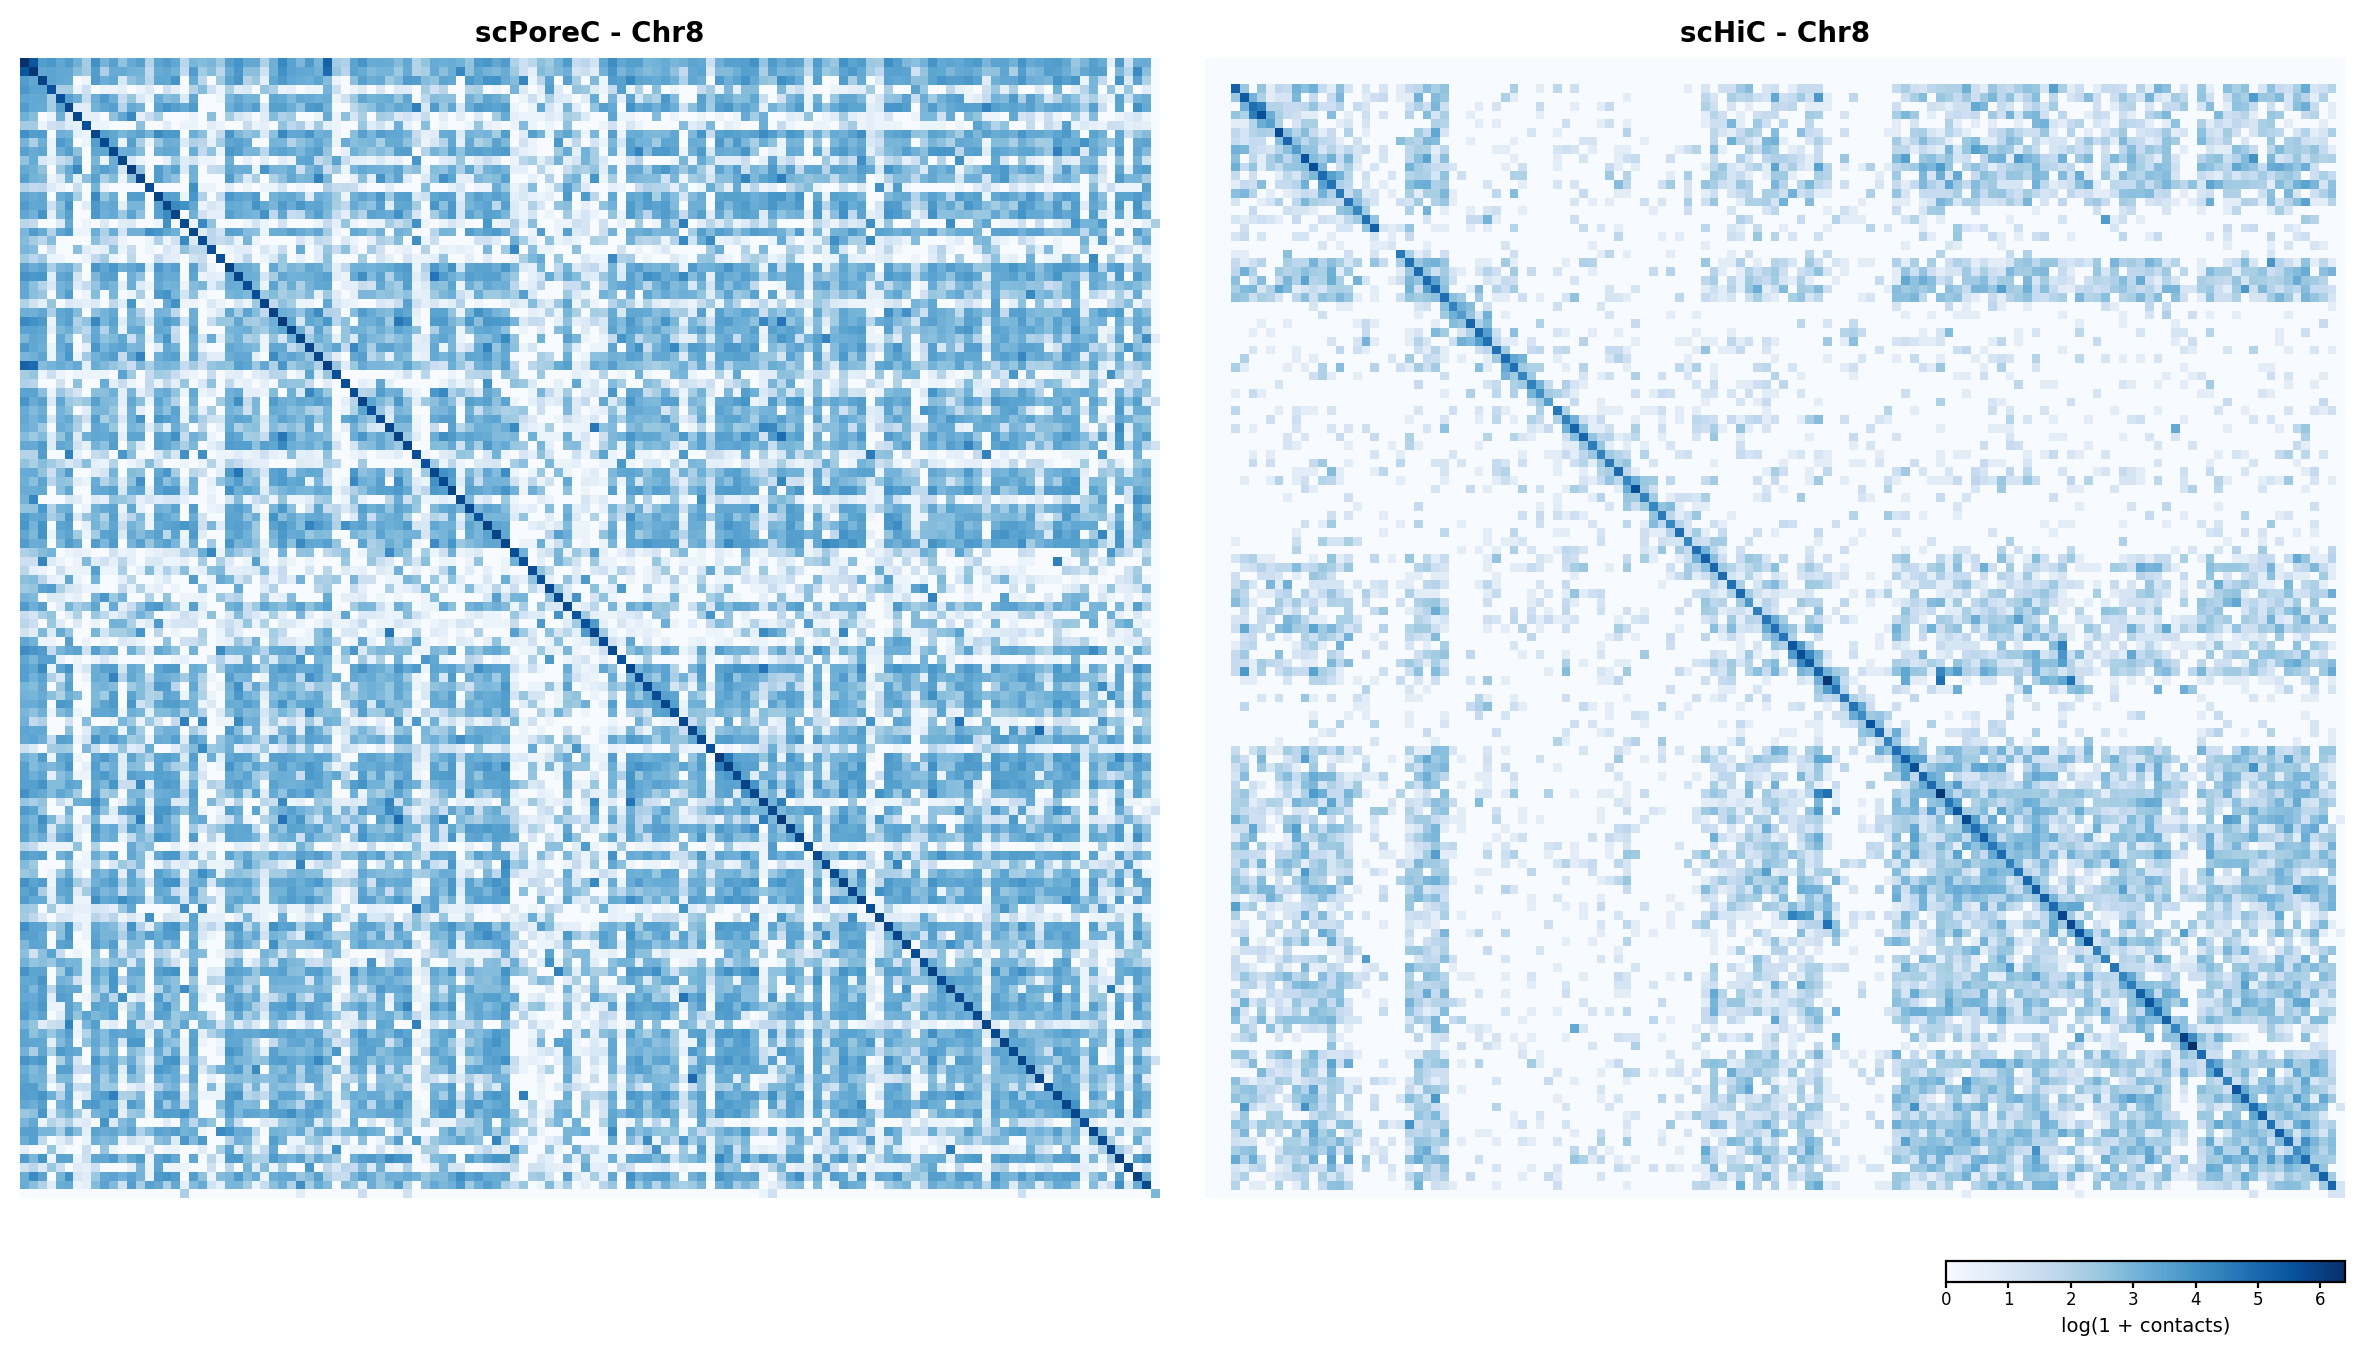

In [14]:
axes, raw = plot_panel_contact(
    sparse_matrix   = cdata_filtered.X,
    numpy_matrix_1  = master_chr,
    spath           = 'chr8panel_contact.png',
    titles          = ('scPoreC - Chr8', 'scHiC - Chr8'),
    log_transform   = True,
    cmap            = 'Blues',
)

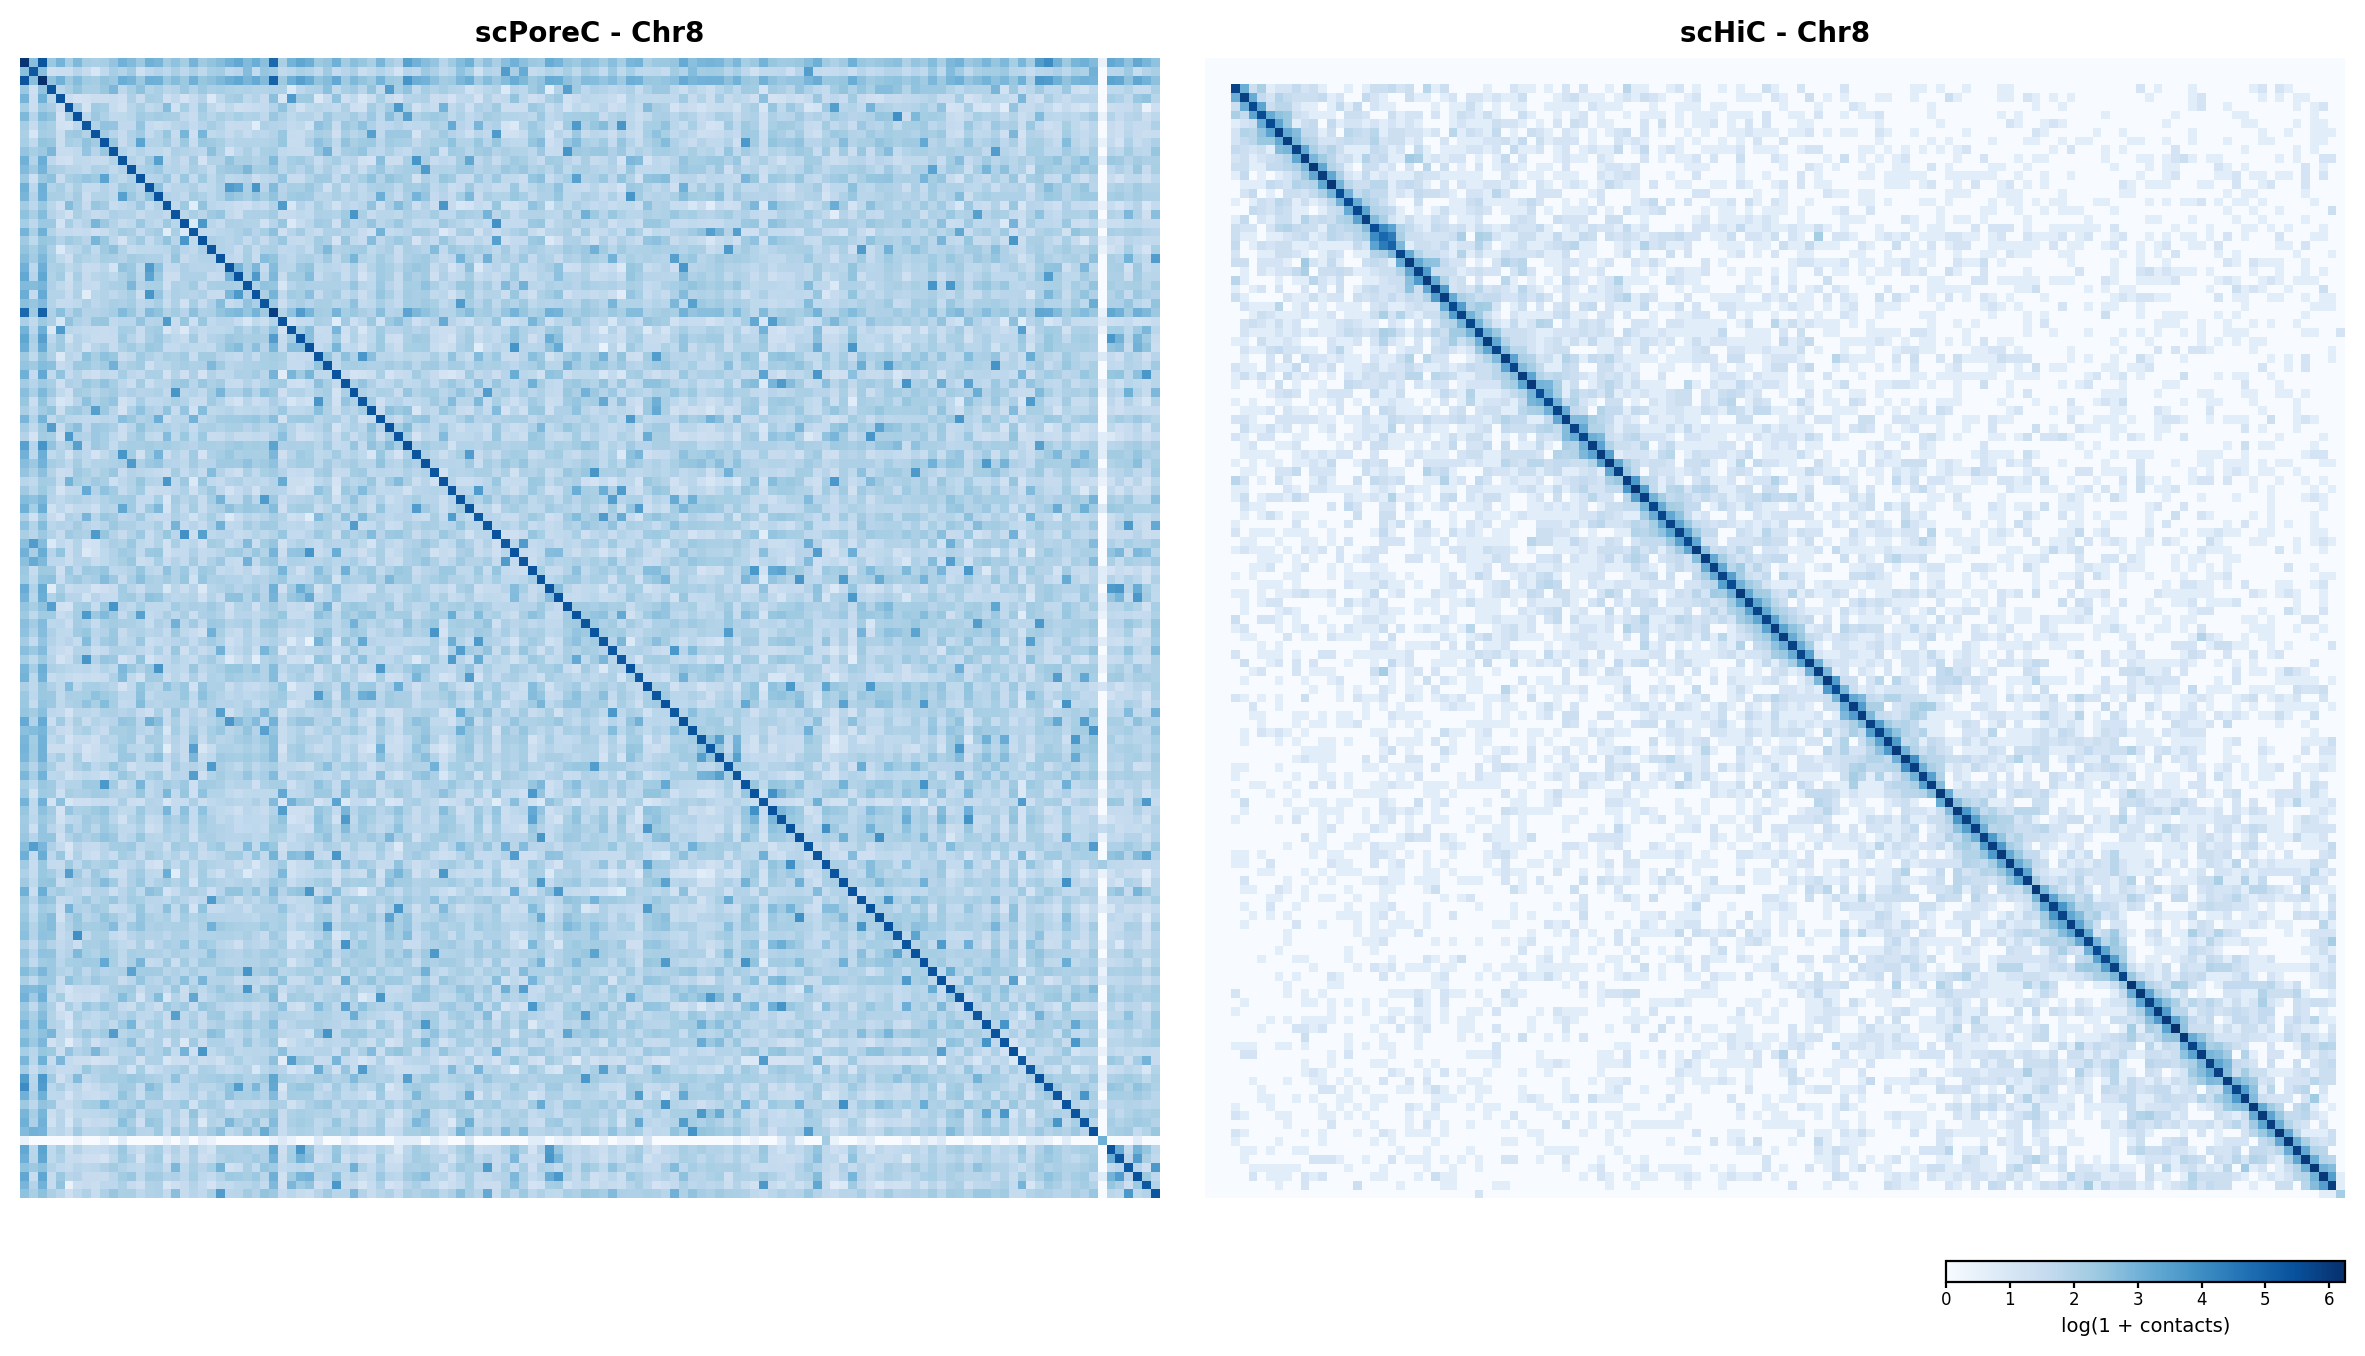

In [81]:
axes, raw = plot_panel_contact(
    sparse_matrix   = adata_filtered.X,
    numpy_matrix_1  = master_pop,
    spath           = 'chr8_panel_contact_pop.png',
    titles          = ('scPoreC - Chr8', 'scHiC - Chr8'),
    log_transform   = True,
    cmap            = 'Blues',
)

### Pearson Correlation Contacts

In [15]:
def load_and_align_matrices(data_dict):
    """
    Parameters:
        data_dict: dictionary with exactly two entries, e.g.:
            {
                "pore_c": sparse_matrix,   # scipy sparse matrix
                "hi_c":   numpy_matrix     # numpy ndarray
            }

    Returns:
        dense1, dense2:    aligned dense numpy arrays
        label1, label2:    keys used as plot labels
    """
    assert len(data_dict) == 2, "Dictionary must contain exactly two matrices."

    labels = list(data_dict.keys())
    matrices = list(data_dict.values())

    label1, label2 = labels[0], labels[1]
    mat1,   mat2   = matrices[0], matrices[1]

    # Convert whichever is sparse to dense
    dense1 = mat1.toarray() if sp.issparse(mat1) else np.array(mat1)
    dense2 = mat2.toarray() if sp.issparse(mat2) else np.array(mat2)

    assert dense1.shape == dense2.shape, (
        f"Shape mismatch: {dense1.shape} vs {dense2.shape}"
    )

    return dense1, dense2, label1, label2

In [16]:
def extract_upper_triangle(mat1, mat2, k=1):
    """
    Extract upper triangular values to avoid double-counting
    symmetric contact matrices.

    k=1 excludes the diagonal (self-interactions)
    """
    idx = np.triu_indices_from(mat1, k=k)

    vals1 = mat1[idx]
    vals2 = mat2[idx]

    return vals1, vals2

In [17]:
def filter_and_correlate(vals1, vals2, log_transform=True, pseudocount=1):
    """
    Optionally log-transform, filter zero/NaN pairs, then correlate.
    """
    vals1 = vals1.astype(float)
    vals2 = vals2.astype(float)

    # Optional log1p transform (recommended for count data)
    if log_transform:
        vals1 = np.log1p(vals1 + pseudocount - 1)  # log1p(vals + pseudocount)
        vals2 = np.log1p(vals2 + pseudocount - 1)

    # Create a mask: keep only pairs where BOTH are finite and non-NaN
    mask = (
        np.isfinite(vals1) & np.isfinite(vals2) &
        ~np.isnan(vals1)   & ~np.isnan(vals2)
    )

    # Optionally exclude bins where both are zero (structural zeros)
    both_nonzero = (vals1 > 0) | (vals2 > 0)
    mask = mask & both_nonzero

    v1_clean = vals1[mask]
    v2_clean = vals2[mask]

    r, pval = pearsonr(v1_clean, v2_clean)
    print(f"Pearson r = {r:.4f}  |  p-value = {pval:.2e}  |  N = {mask.sum():,}")

    return v1_clean, v2_clean, r, pval

In [18]:
def plot_correlation(v1, v2, r, pval,
                     label1="Pore-C", label2="Hi-C",
                     chrom="chr1",
                     point_alpha=0.3,
                     density=True):
    """
    Scatter plot of Pore-C vs Hi-C contact values per bin pair.
    Uses 2D histogram density coloring for large datasets.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    if density:
        # Hexbin for large N — handles overplotting well
        hb = ax.hexbin(v1, v2,
                       gridsize=80,
                       cmap="YlOrRd",
                       mincnt=1,
                       linewidths=0.1)
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Count per bin", fontsize=11)
    else:
        ax.scatter(v1, v2,
                   alpha=point_alpha,
                   s=5,
                   color="steelblue",
                   edgecolors="none")

    # Regression line
    m, b = np.polyfit(v1, v2, 1)
    x_line = np.linspace(v1.min(), v1.max(), 300)
    ax.plot(x_line, m * x_line + b,
            color="crimson", linewidth=1.8,
            label=f"Fit: y = {m:.2f}x + {b:.2f}")

    # Annotate Pearson r
    ax.text(0.05, 0.93,
            f"Pearson r = {r:.3f}\np = {pval:.2e}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', alpha=0.8))

    ax.set_xlabel(f"{label1} contacts (log1p)", fontsize=12)
    ax.set_ylabel(f"{label2} contacts (log1p)", fontsize=12)
    ax.set_title(f"{label1} vs {label2} — {chrom}", fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(f"porec_hic_pearson_{chrom}.png", dpi=150)
    plt.show()
    print("Plot saved.")

In [19]:
dense1, dense2, label1, label2 = load_and_align_matrices(raw)

AssertionError: Shape mismatch: (128, 128) vs (131, 131)

In [ ]:
v1, v2 = extract_upper_triangle(dense1, dense2, k=1)

In [ ]:
v1_clean, v2_clean, r, pval = filter_and_correlate(
    v1, v2,
    log_transform=True,   # set False if already normalized (e.g., OE, ICE)
    pseudocount=1
)

In [ ]:
plot_correlation(
    v1_clean, v2_clean, r, pval,
    label1="Pore-C",
    label2="Hi-C",
    chrom="chr1",
    density=True          # set False if N is small (<10k points)
)